<a href="https://colab.research.google.com/github/hamnasz/DevByte/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Visualization & Analysis
**DevByte AI/ML Internship — BETA Project**

**Assigned:** 2026-06-30 &nbsp;|&nbsp; **Due:** 2026-07-14

This notebook covers:
- Histograms (distribution of numeric columns)
- Scatterplots (relationships between variables)
- Correlation Matrix (heatmap)
- Charts: Bar, Line, Box, Pie, and Count plots

Libraries used: **Matplotlib** and **Seaborn**

## Step 1: Install & Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global style settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

print('Libraries loaded.')

Libraries loaded.


## Step 2: Generate / Load the Dataset

We reuse the same sales dataset from the data-cleaning task so all plots reflect the same data pipeline. To use your own cleaned CSV instead, replace the generation block with:
```python
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
```

In [ ]:
import random
random.seed(42)
np.random.seed(42)

n = 300
regions     = ['North', 'South', 'East', 'West']
categories  = ['Electronics', 'Apparel', 'Grocery', 'Furniture']

def rand_date_range():
    s = pd.Timestamp('2025-01-01') + pd.Timedelta(days=random.randint(0, 360))
    e = s + pd.Timedelta(days=random.randint(1, 30))
    return s, e

starts, ends = zip(*[rand_date_range() for _ in range(n)])

df = pd.DataFrame({
    'customer_id'      : range(1001, 1001 + n),
    'region'           : [random.choice(regions) for _ in range(n)],
    'product_category' : [random.choice(categories) for _ in range(n)],
    'order_amount_pkr' : np.round(np.random.uniform(500, 50000, n), 2),
    'quantity'         : np.random.randint(1, 21, n),
    'rating'           : np.round(np.random.uniform(1.0, 5.0, n), 1),
    'start_date'       : pd.to_datetime(list(starts)),
    'end_date'         : pd.to_datetime(list(ends)),
})

df['duration_days']   = (df['end_date'] - df['start_date']).dt.days
df['revenue']         = df['order_amount_pkr'] * df['quantity']
df['month']           = df['start_date'].dt.to_period('M').astype(str)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (300, 11)


,customer_id,region,product_category,order_amount_pkr,quantity,rating,start_date,end_date,duration_days,revenue,month
0,1001,North,Electronics,19039.74,13,3.2,2025-11-24,2025-11-28,4,247516.62,2025-11
1,1002,East,Apparel,47560.36,20,4.5,2025-01-13,2025-02-06,24,951207.20,2025-01
2,1003,East,Apparel,36733.70,15,2.6,2025-05-21,2025-05-29,8,551005.50,2025-05
3,1004,West,Grocery,30133.59,3,1.5,2025-04-25,2025-04-30,5,90400.77,2025-04
4,1005,East,Electronics,8222.92,8,1.1,2025-02-22,2025-03-16,22,65783.36,2025-02


---
## Part A: Histograms
Histograms show how values are spread out in a column. Think of them like a frequency count — which range of values shows up the most.

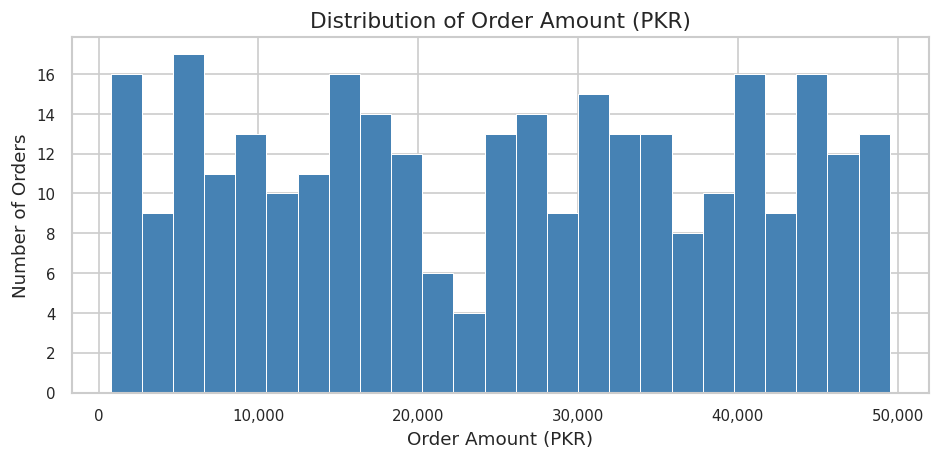

In [ ]:
# --- A1: Order Amount Distribution (Matplotlib) ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['order_amount_pkr'], bins=25, color='steelblue', edgecolor='white', linewidth=0.6)
ax.set_title('Distribution of Order Amount (PKR)')
ax.set_xlabel('Order Amount (PKR)')
ax.set_ylabel('Number of Orders')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('hist_order_amount.png', bbox_inches='tight')
plt.show()

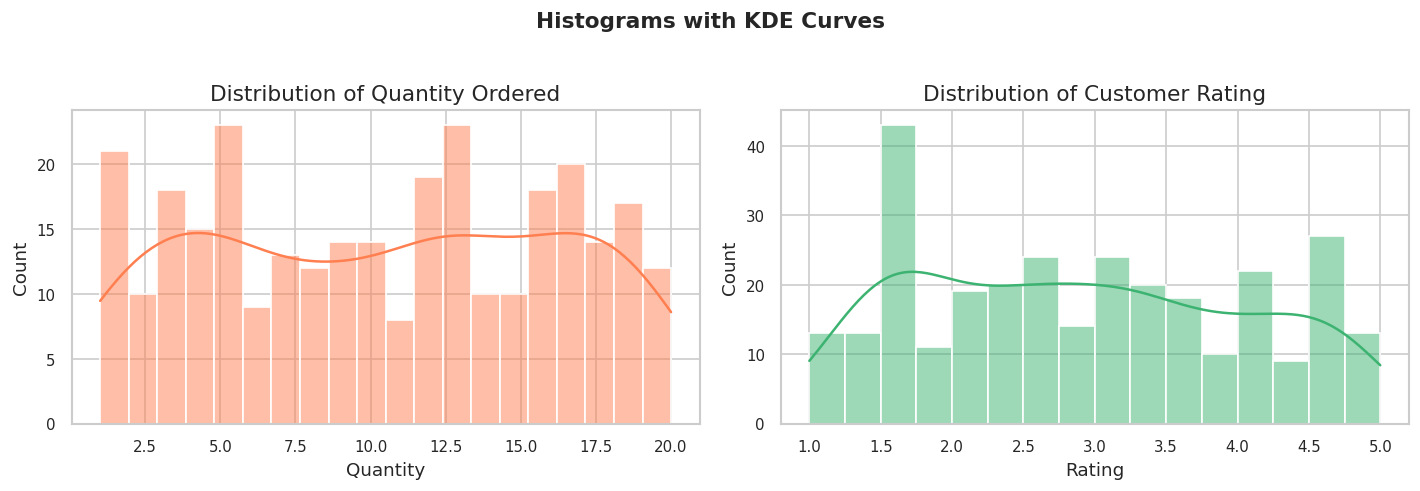

In [ ]:
# --- A2: Quantity & Rating side by side (Seaborn) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['quantity'], bins=20, kde=True, color='coral', ax=axes[0])
axes[0].set_title('Distribution of Quantity Ordered')
axes[0].set_xlabel('Quantity')

sns.histplot(df['rating'], bins=16, kde=True, color='mediumseagreen', ax=axes[1])
axes[1].set_title('Distribution of Customer Rating')
axes[1].set_xlabel('Rating')

plt.suptitle('Histograms with KDE Curves', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hist_qty_rating.png', bbox_inches='tight')
plt.show()

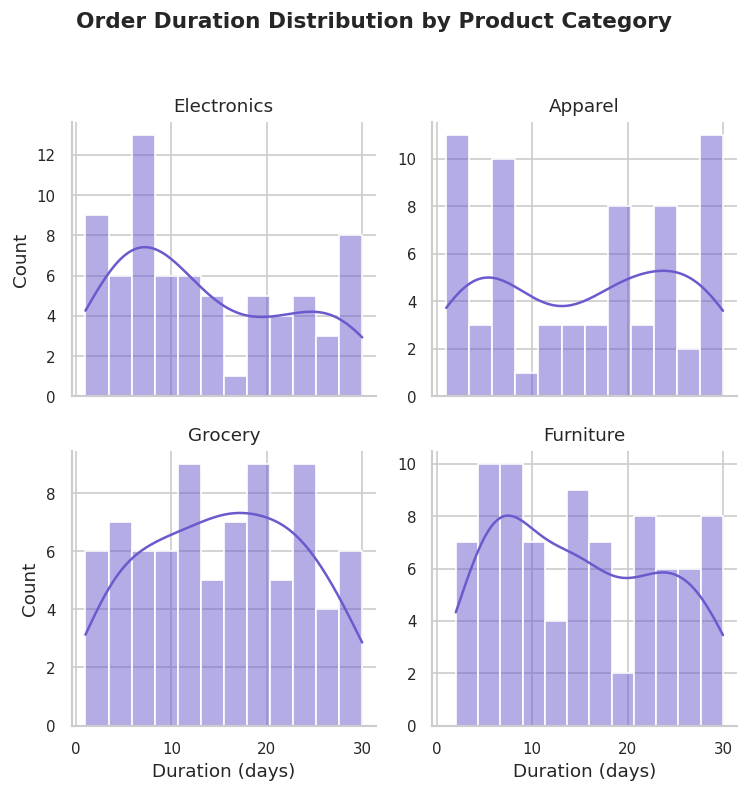

In [ ]:
# --- A3: Duration Days by Category (Seaborn FacetGrid) ---
g = sns.FacetGrid(df, col='product_category', col_wrap=2, height=3.2, sharey=False)
g.map(sns.histplot, 'duration_days', bins=12, color='slateblue', kde=True)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('Duration (days)', 'Count')
g.figure.suptitle('Order Duration Distribution by Product Category', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hist_duration_facet.png', bbox_inches='tight')
plt.show()

---
## Part B: Scatterplots
Scatterplots show how two numeric columns relate to each other. Each dot is one order. If the dots go up together, the two things are positively related.

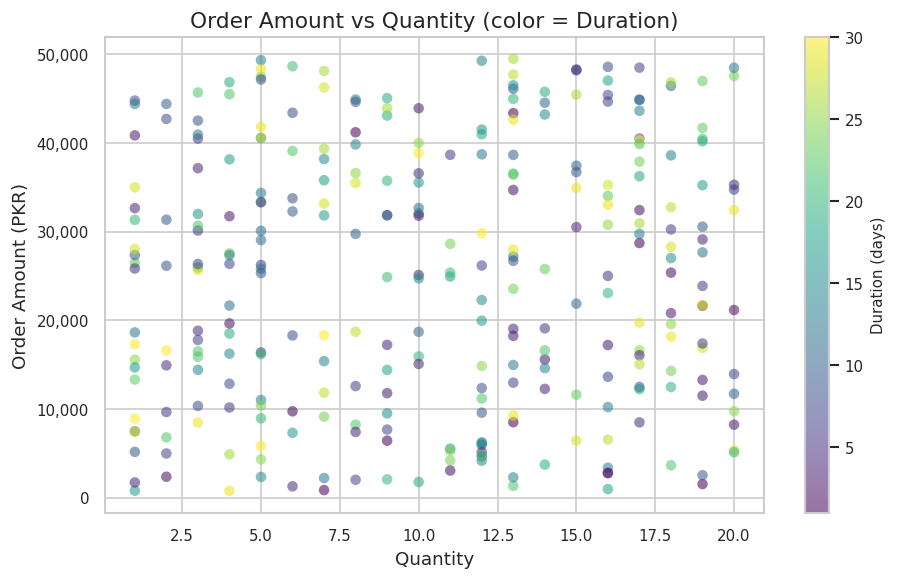

In [ ]:
# --- B1: Order Amount vs Quantity (Matplotlib) ---
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df['quantity'],
    df['order_amount_pkr'],
    alpha=0.55, s=40,
    c=df['duration_days'], cmap='viridis',
    edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Duration (days)', fontsize=9)
ax.set_title('Order Amount vs Quantity (color = Duration)')
ax.set_xlabel('Quantity')
ax.set_ylabel('Order Amount (PKR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('scatter_amount_qty.png', bbox_inches='tight')
plt.show()

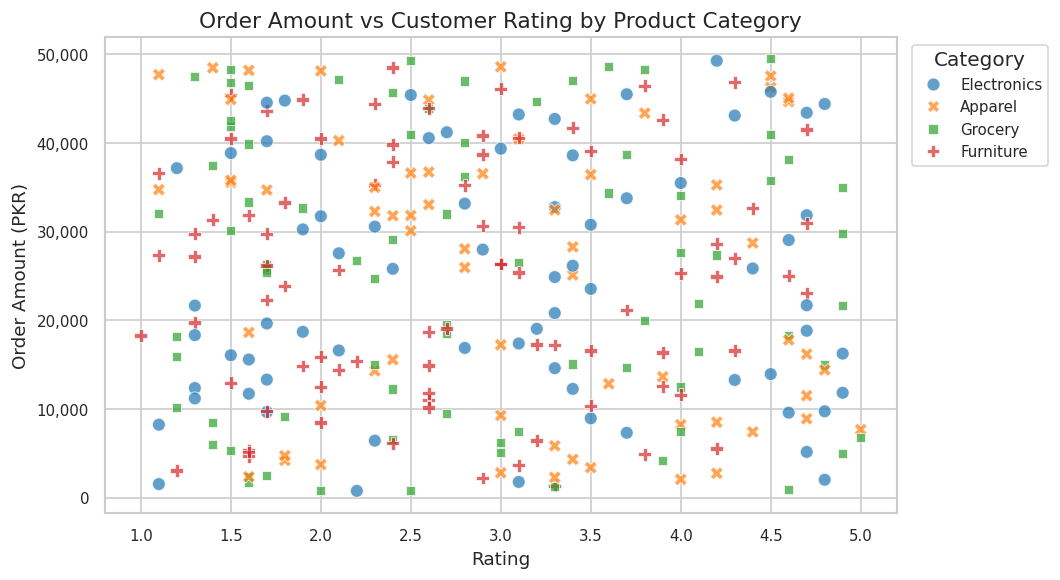

In [ ]:
# --- B2: Order Amount vs Rating colored by Category (Seaborn) ---
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=df, x='rating', y='order_amount_pkr',
    hue='product_category', style='product_category',
    palette='tab10', alpha=0.7, s=60, ax=ax
)
ax.set_title('Order Amount vs Customer Rating by Product Category')
ax.set_xlabel('Rating')
ax.set_ylabel('Order Amount (PKR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('scatter_rating_category.png', bbox_inches='tight')
plt.show()

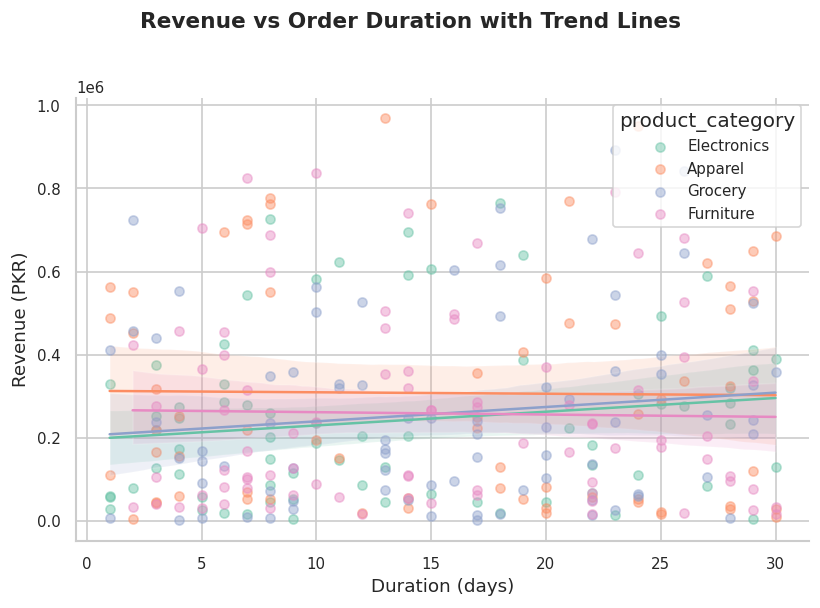

In [ ]:
# --- B3: Revenue vs Duration with regression lines per Category (Seaborn lmplot) ---
g = sns.lmplot(
    data=df, x='duration_days', y='revenue',
    hue='product_category', palette='Set2',
    scatter_kws={'alpha': 0.45, 's': 30},
    line_kws={'linewidth': 1.5},
    height=5, aspect=1.4, legend_out=False
)
g.set_axis_labels('Duration (days)', 'Revenue (PKR)')
g.figure.suptitle('Revenue vs Order Duration with Trend Lines', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scatter_revenue_duration.png', bbox_inches='tight')
plt.show()

---
## Part C: Correlation Matrix
A correlation matrix shows how strongly each pair of numeric columns is related. Values close to 1.0 mean they go up together. Values close to -1.0 mean one goes up as the other goes down. Values near 0 mean no relationship.

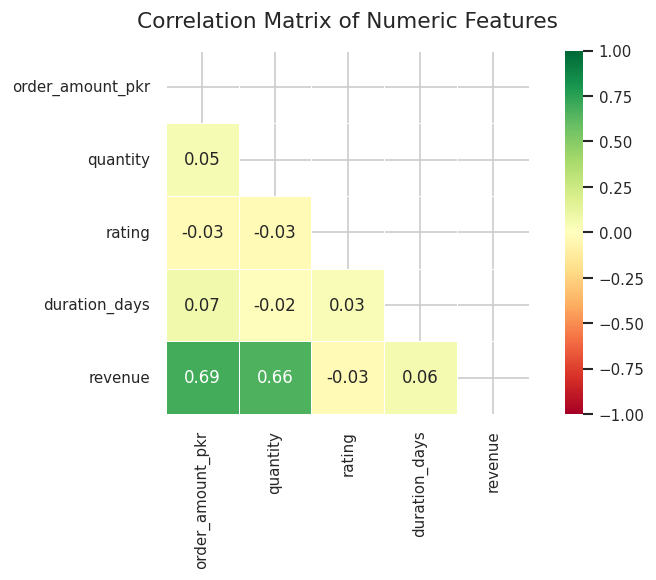

In [ ]:
# --- C1: Full Correlation Heatmap (Seaborn) ---
numeric_cols = ['order_amount_pkr', 'quantity', 'rating', 'duration_days', 'revenue']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    annot_kws={'size': 10}, ax=ax
)
ax.set_title('Correlation Matrix of Numeric Features', pad=14)
plt.tight_layout()
plt.savefig('corr_matrix.png', bbox_inches='tight')
plt.show()

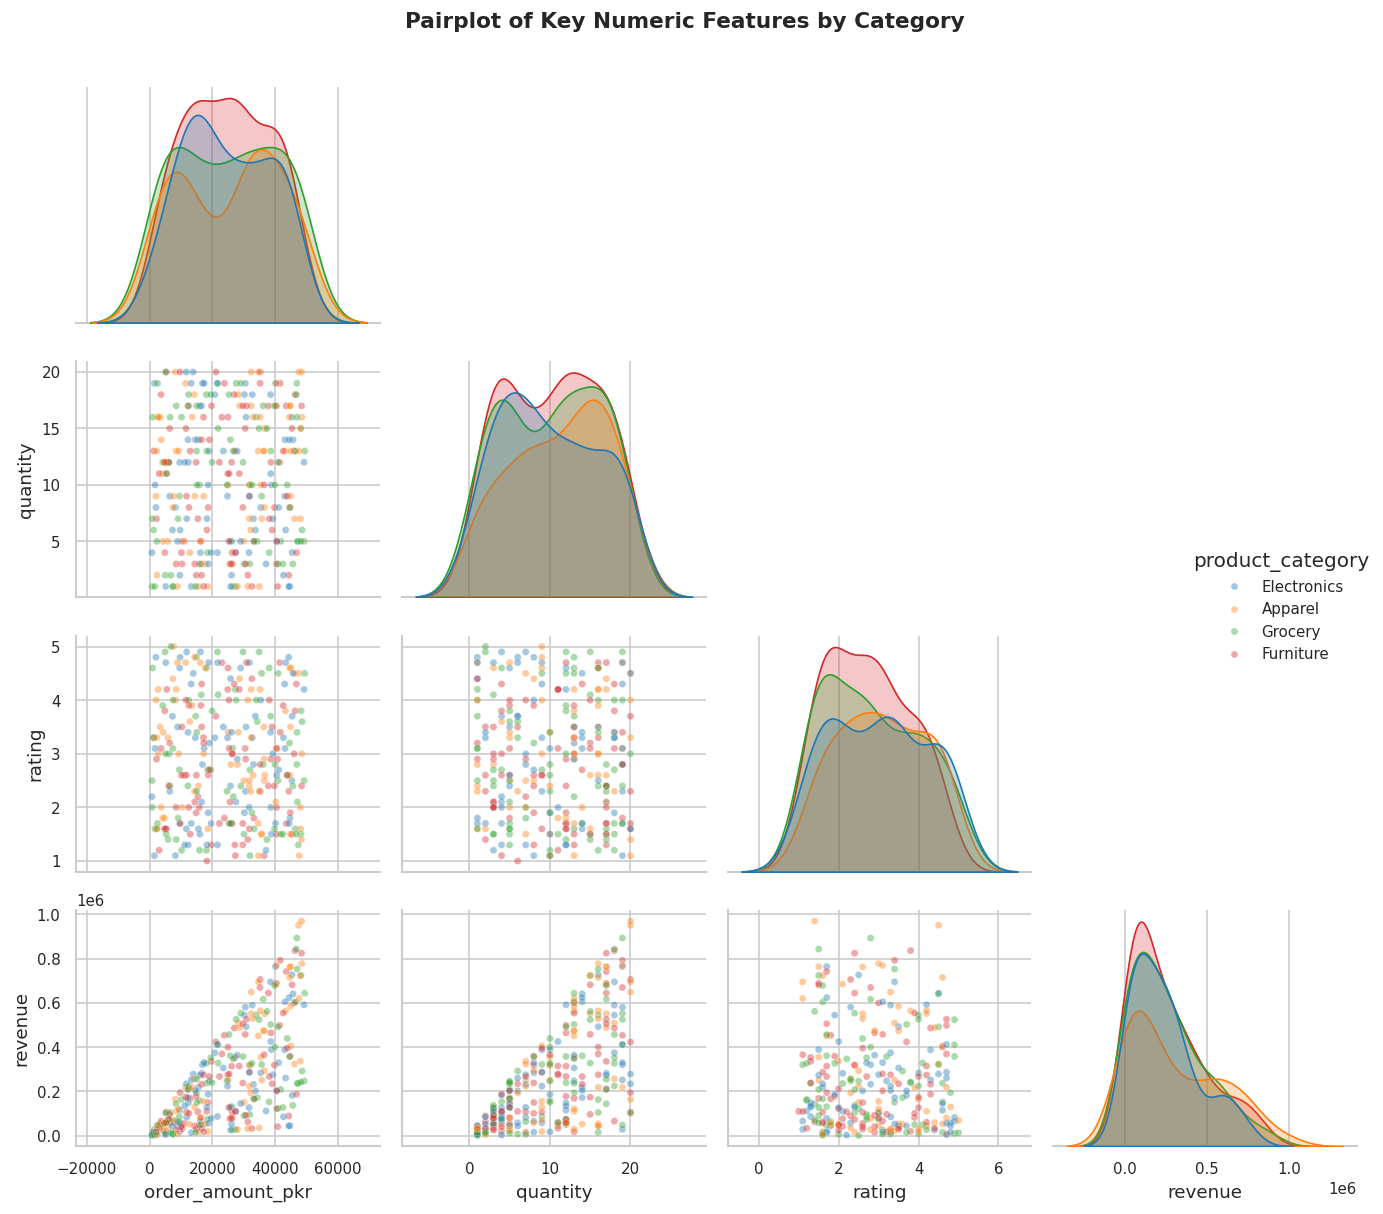

In [ ]:
# --- C2: Pairplot for deeper pairwise insight (Seaborn) ---
pair_df = df[['order_amount_pkr', 'quantity', 'rating', 'revenue', 'product_category']].copy()
g = sns.pairplot(
    pair_df, hue='product_category', palette='tab10',
    plot_kws={'alpha': 0.4, 's': 18},
    diag_kind='kde', corner=True
)
g.figure.suptitle('Pairplot of Key Numeric Features by Category', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()

---
## Part D: Charts
Different chart types for different business questions.

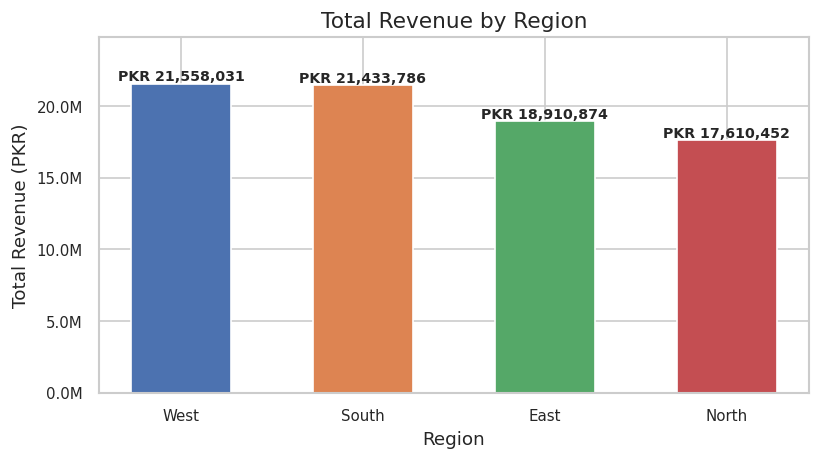

In [ ]:
# --- D1: Bar Chart — Total Revenue by Region (Matplotlib) ---
rev_region = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rev_region.index, rev_region.values, color=colors, edgecolor='white', width=0.55)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15000,
        f'PKR {bar.get_height():,.0f}',
        ha='center', va='bottom', fontsize=8.5, fontweight='bold'
    )

ax.set_title('Total Revenue by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Total Revenue (PKR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_ylim(0, rev_region.max() * 1.15)
plt.tight_layout()
plt.savefig('bar_revenue_region.png', bbox_inches='tight')
plt.show()

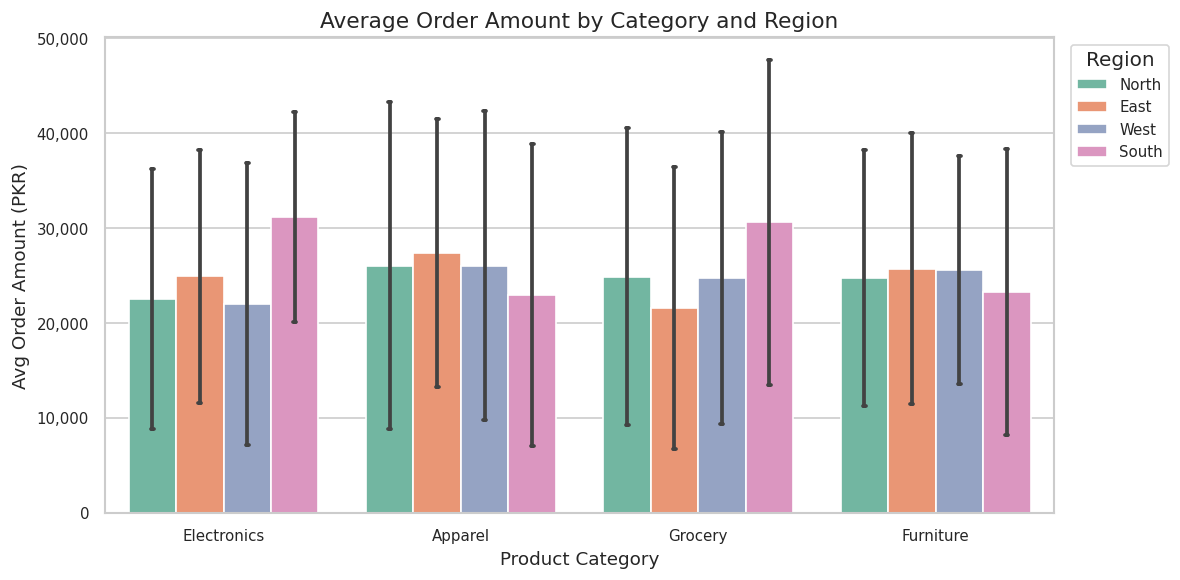

In [ ]:
# --- D2: Grouped Bar Chart — Avg Order Amount by Category and Region (Seaborn) ---
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=df, x='product_category', y='order_amount_pkr',
    hue='region', palette='Set2', errorbar='sd',
    capsize=0.05, ax=ax
)
ax.set_title('Average Order Amount by Category and Region')
ax.set_xlabel('Product Category')
ax.set_ylabel('Avg Order Amount (PKR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('bar_grouped_category_region.png', bbox_inches='tight')
plt.show()

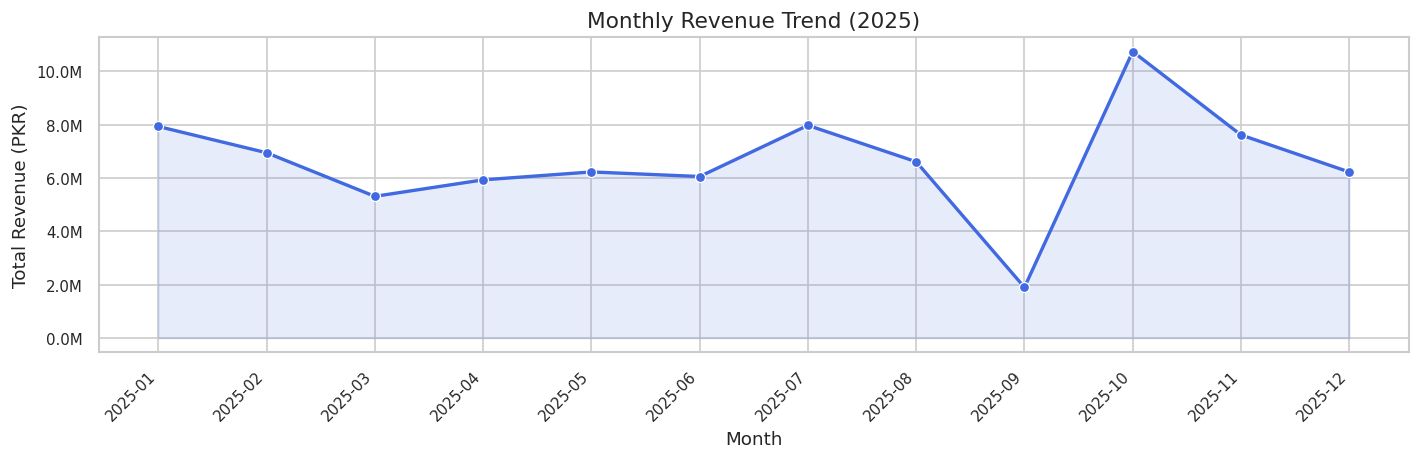

In [ ]:
# --- D3: Line Chart — Monthly Revenue Trend (Matplotlib + Seaborn) ---
monthly = df.groupby('month')['revenue'].sum().reset_index()
monthly = monthly.sort_values('month')

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=monthly, x='month', y='revenue', marker='o', color='royalblue', linewidth=2, ax=ax)
ax.fill_between(monthly['month'], monthly['revenue'], alpha=0.12, color='royalblue')
ax.set_title('Monthly Revenue Trend (2025)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (PKR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('line_monthly_revenue.png', bbox_inches='tight')
plt.show()

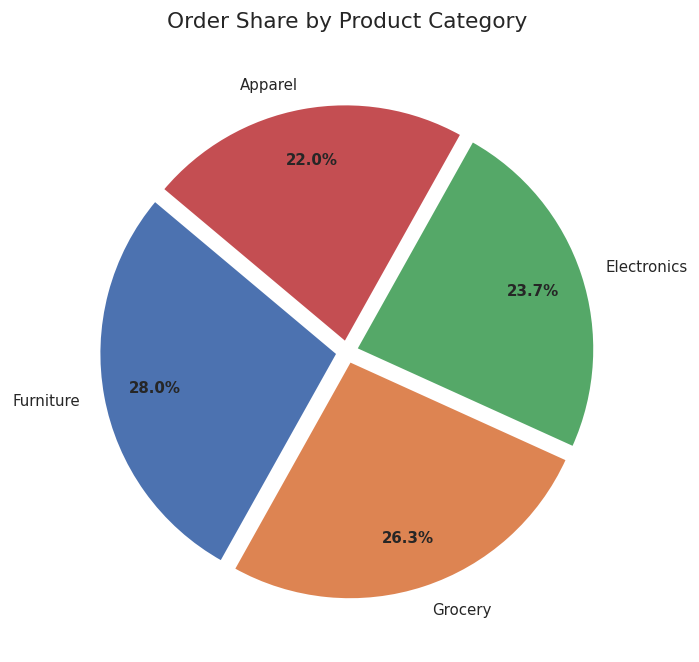

In [ ]:
# --- D4: Pie Chart — Order Share by Product Category (Matplotlib) ---
cat_counts = df['product_category'].value_counts()
explode    = [0.04] * len(cat_counts)
colors_pie = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    explode=explode,
    colors=colors_pie,
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')

ax.set_title('Order Share by Product Category', pad=16)
plt.tight_layout()
plt.savefig('pie_category.png', bbox_inches='tight')
plt.show()

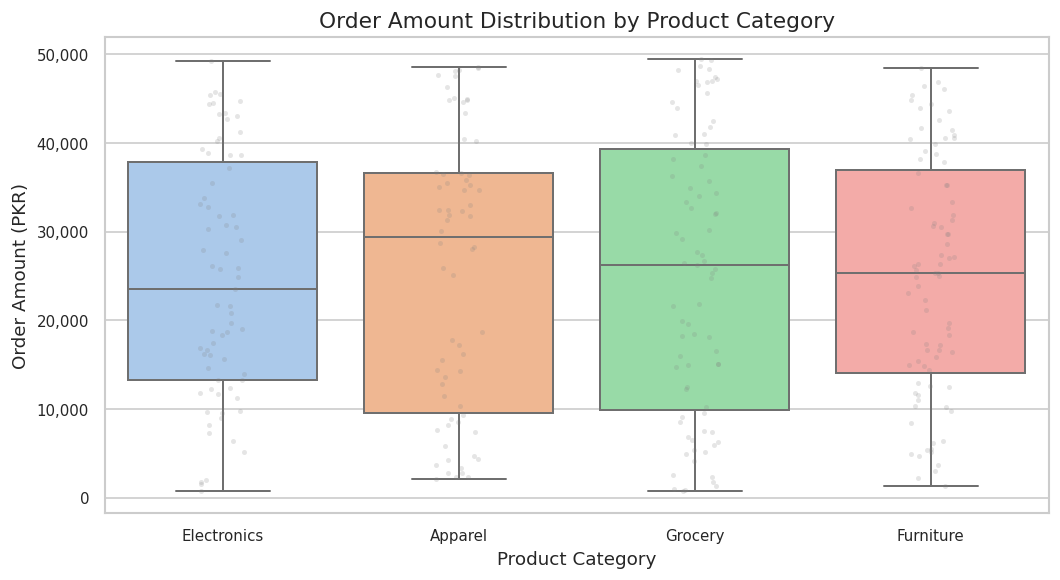

In [ ]:
# --- D5: Box Plot — Order Amount Distribution by Category (Seaborn) ---
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df, x='product_category', y='order_amount_pkr',
    palette='pastel', linewidth=1.2, flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5},
    ax=ax
)
sns.stripplot(
    data=df, x='product_category', y='order_amount_pkr',
    color='gray', alpha=0.2, size=3, jitter=True, ax=ax
)
ax.set_title('Order Amount Distribution by Product Category')
ax.set_xlabel('Product Category')
ax.set_ylabel('Order Amount (PKR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('box_amount_category.png', bbox_inches='tight')
plt.show()

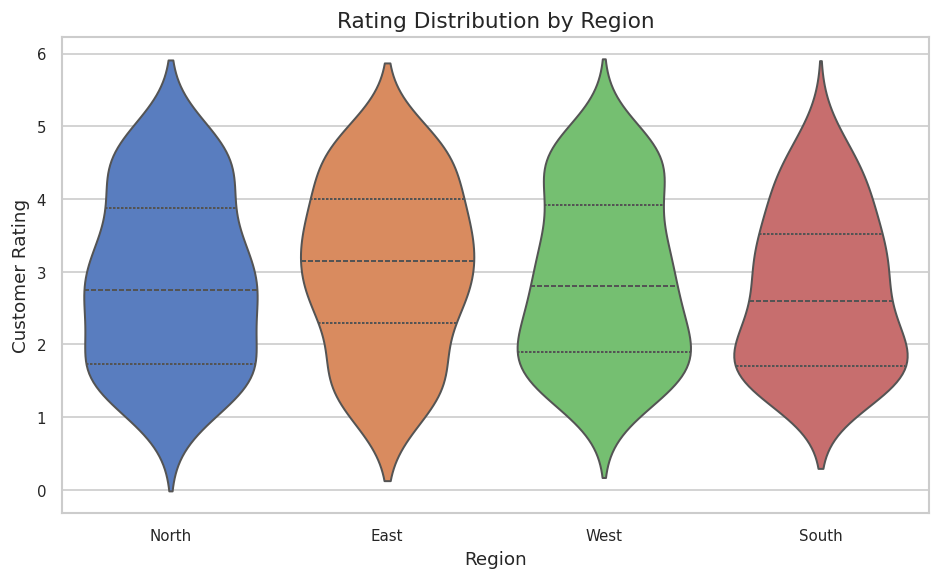

In [ ]:
# --- D6: Violin Plot — Rating by Region (Seaborn) ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=df, x='region', y='rating',
    palette='muted', inner='quartile', linewidth=1.2, ax=ax
)
ax.set_title('Rating Distribution by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Customer Rating')
plt.tight_layout()
plt.savefig('violin_rating_region.png', bbox_inches='tight')
plt.show()

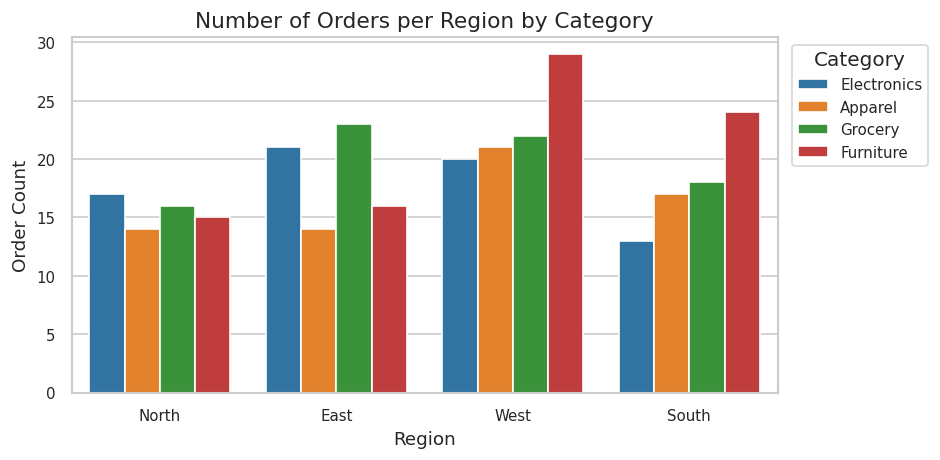

In [ ]:
# --- D7: Count Plot — Orders per Region (Seaborn) ---
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(
    data=df, x='region', hue='product_category',
    palette='tab10', edgecolor='white', ax=ax
)
ax.set_title('Number of Orders per Region by Category')
ax.set_xlabel('Region')
ax.set_ylabel('Order Count')
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('count_region_category.png', bbox_inches='tight')
plt.show()

---
## Summary

| Chart Type | Plot | Key Insight |
|---|---|---|
| Histogram | Order Amount | Orders spread fairly evenly across all price ranges |
| Histogram + KDE | Quantity, Rating | Ratings cluster near the middle; quantity is roughly uniform |
| Histogram FacetGrid | Duration by Category | Each category has a similar order duration pattern |
| Scatterplot | Amount vs Quantity | No strong linear trend; orders are varied |
| Scatterplot | Rating vs Amount | Rating does not heavily influence order value |
| Scatter + Regression | Revenue vs Duration | Slight positive trend in most categories |
| Correlation Heatmap | All numerics | Revenue correlates with both amount and quantity as expected |
| Pairplot | Key features | No hidden strong correlations outside revenue |
| Bar Chart | Revenue by Region | All four regions perform comparably |
| Grouped Bar | Avg Amount by Cat+Region | Prices are consistent across regions within each category |
| Line Chart | Monthly Revenue | Revenue remains stable throughout the year |
| Pie Chart | Category Share | Orders are distributed nearly equally across categories |
| Box + Strip | Amount by Category | Furniture tends to have slightly higher order amounts |
| Violin | Rating by Region | Rating distributions are similar across all regions |
| Count Plot | Orders by Region+Cat | East and West lead slightly in total order volume |